# Capstone: Define and Solve an ML Problem

In [1]:
import pandas as pd
import numpy as np
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow.keras as keras
from sklearn.preprocessing import StandardScaler
import time

**Note**: As you work through the notebook, you can import additional packages as needed.

## Overview


In this capstone assignment, you will follow the machine learning life cycle and implement one of the supervised learning models you have learned so far in this course, along with a neural network, to solve a predictive problem.

This capstone spans two lab sessions.

- **Unit 5 Lab:** You will define a machine learning problem, explore and prepare your data, and train, test, evaluate and improve a traditional machine learning model (Parts 1–5).
- **Unit 6 Lab:** After completing Unit 6 on neural networks, you will apply a neural network to the same problem and compare the two approaches (Parts 6–7).

There is a checkpoint at the end of Part 5 that marks where to stop during the Unit 5 lab.

You will complete the following:

1. Choose your Data Set and Build Your DataFrame
2. Define Your ML Problem
3. Understand Your Data
4. Prepare Your Data
5. Train, Test, Evaluate and Improve a Traditional Machine Learning Model *(Unit 5 lab)*
6. Train, Test, Evaluate and Improve Neural Network *(Unit 6 lab)*
7. Compare Your Models and Reflect *(Unit 6 lab)*

**This is an individual assignment.** You are welcome to discuss ideas with your peers, but the code and written responses you submit must be your own.

**Note:** This capstone is intentionally less scaffolded than your weekly labs; that is by design. You are expected to make your own implementation choices, add code cells as needed, and document your reasoning throughout.

## Part 1: Choose Your Data Set and Build Your DataFrame


You will choose one of two data sets to work with for this capstone. In both cases, you will be solving a supervised learning binary classification problem by predicting one of two possible class labels. Both data sets have been used earlier in the course, so you are already familiar with their structure. 

**Option A: Census Income Data** (`censusData.csv`)
This data set contains demographic and employment information from the 1994 U.S. Census. You will use it to predict whether an individual's annual income exceeds $50,000. Your label column is `income_binary`, which contains two values: `<=50K` and `>50K`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Option B: Airbnb NYC Listings Data** (`airbnbListingsData.csv`)
This data set contains information about Airbnb listings in New York City. You will use it to predict whether a listing is high-priced. The data set includes a new `price_category` column that classifies each listing as either "high price" or "low price" based on whether the listing’s price falls above or below the 75th percentile of all listing prices. Listings at or above the 75th percentile are labeled as `high`, while the remaining listings are labeled as `low`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Note:**  These versions of the data sets differ slightly from the versions you have worked with in this program. For example, they may not include some of the preprocessing necessary for specific models. 

#### Load a Data Set and Save it as a Pandas DataFrame

The code cell below contains filenames (path + filename) for the two data sets available to you.

<b>Task:</b> In the code cell below, load your chosen data set using `pd.read_csv()` and save it to a DataFrame named `df`. Then call `df.head()` to inspect the first few row of the data set.

In [ ]:
# File paths for both data sets
census_filename = os.path.join(os.getcwd(), "data_capstone", "censusData.csv")

# Load your chosen dataset and save it to df
df = pd.read_csv(census_filename)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Non-Female,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Non-Female,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Non-Female,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


## Part 2: Define Your ML Problem

The first step of the machine learning life cycle involves defining your business problem. In the markdown cell below, you will clearly define what you are trying to predict and why it matters. 

<b>Task</b>: In the markdown cell below, answer all of the following questions:

1. Which data set did you choose?
2. What is your label? What are you predicting?
3. What features do you plan to use? (This list may change after you explore your data.)
5. Why does this problem matter? Using the business brief you read in the lab overview page, explain how the organization described there could use a model that predicts this label to create value or inform decisions for their client.

1. I chose the census dataset.
2. The label is income_binary, which defines if income is less than or equal to 50k, or greater than 50k. We are predicting if an individual's annual income would be greater than, or less than or equal to 50k.
3. I plan to use occupation, capital gain, capital loss, age, workclass, education.
4. This problem matters because it can help the client make more accurate recommendations for program eligibility, and allows for scalability of this process. This would help the client expand their reach without having to strain internal resources. Building a machine learning solution would allow the client to make reliable and consistent decisions for program eligibility, and specifically, determining annual income. This benefits both the client and their customers.

## Part 3: Understand Your Data

Now that you have defined your problem, perform exploratory data analysis (EDA) with that problem in mind. Consider the following as you inspect your data:

1. What data preparation techniques would you like to use? These data preparation techniques may include:

    * handling missing values
    * finding and replacing outliers
    * performing feature engineering techniques such as one-hot encoding on categorical features
    * selecting appropriate features and removing irrelevant features
    * addressing class imbalance


2. What machine learning model would you like to use that is suitable for your predictive problem and data?
   * You may use one of the following models that you have worked with so far:
        - K-Nearest Neighbors (KNN)
        - Decision Tree
        - Logistic Regression
   * Are there other data preparation techniques that you will need to apply to build a balanced modeling data set for your problem and model? For example, will you need to scale your data?
 

3. How will you evaluate and improve the model's performance?
    * Are there specific evaluation metrics or methods that are appropriate for your problem, dataset, or selected model?
    
<b>Task</b>: In the code cells below, use the techniques you have learned in this course to inspect and analyze your data.

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

### Class Imbalance

Examine the distribution of your label column to determine whether class imbalance is present. Use at least one visualization to show the class distribution. In the **EDA Summary** below, you will discuss how you plan to address any observed imbalance during data preparation.

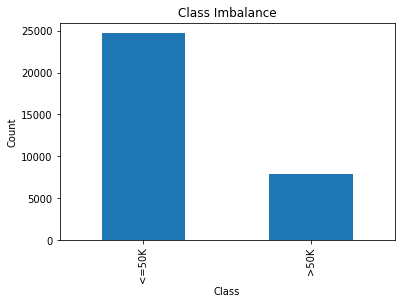

In [3]:
label = "income_binary"
df[label].value_counts().plot(kind="bar")
plt.title("Class Imbalance")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [4]:
print(df["income_binary"].value_counts(normalize=True) * 100)

<=50K    75.919044
>50K     24.080956
Name: income_binary, dtype: float64


### Inspect and Analyze Your Data

Explore your features. Use summary statistics and visualizations to understand how your features are distributed and how they relate to the label. Identify issues such as missing values, outliers, or a feature that is irrelevant or redundant.

Think of the different techniques you have used to inspect and analyze your data in this course. These include using Pandas to apply data filters, using the Pandas `describe()` method to get insight into key statistics for each column, using the Pandas `dtypes` property to inspect the data type of each column, and using Matplotlib and Seaborn to detect outliers and visualize relationships between features and labels. 

Use at least one plot that visualizes a relationship between features and the label.

In [5]:
df.shape

(32561, 15)

In [6]:
df_summ = df.describe()
df_summ

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32399.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32236.000000
mean,38.589216,1.897784e+05,10.080679,615.907773,87.303830,40.450428
std,13.647862,1.055500e+05,2.572720,2420.191974,402.960219,12.353748
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,14084.000000,4356.000000,99.000000


In [7]:
df_summ_all = df.describe(include="all")
df_summ_all

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary
count,32399.000000,30725,3.256100e+04,32561,32561.000000,32561,30718,32561,32561,32561,32561.000000,32561.000000,32236.000000,31978,32561
unique,NaN,8,NaN,16,NaN,7,14,6,5,2,NaN,NaN,NaN,41,2
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Non-Female,NaN,NaN,NaN,United-States,<=50K
freq,NaN,22696,NaN,10501,NaN,14976,4140,13193,27816,21790,NaN,NaN,NaN,29170,24720
mean,38.589216,NaN,1.897784e+05,NaN,10.080679,NaN,NaN,NaN,NaN,NaN,615.907773,87.303830,40.450428,NaN,NaN
std,13.647862,NaN,1.055500e+05,NaN,2.572720,NaN,NaN,NaN,NaN,NaN,2420.191974,402.960219,12.353748,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.178270e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.783560e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.370510e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


In [8]:
df_summ.loc['std'].idxmax(axis=1, skipna=True)

'fnlwgt'

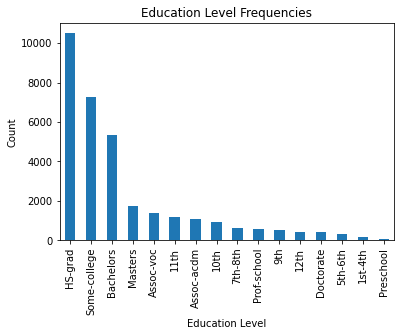

In [9]:
df["education"].value_counts().plot(kind="bar")
plt.title("Education Level Frequencies")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.show()

In [10]:
df.dtypes

age               float64
workclass          object
fnlwgt              int64
education          object
education-num       int64
marital-status     object
occupation         object
relationship       object
race               object
sex_selfID         object
capital-gain        int64
capital-loss        int64
hours-per-week    float64
native-country     object
income_binary      object
dtype: object

In [11]:
corr_matrix = df.corr()
corr_matrix

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.000000,-0.076267,0.036761,0.124901,0.057545,0.067066
fnlwgt,-0.076267,1.000000,-0.043195,-0.002234,-0.010252,-0.018130
education-num,0.036761,-0.043195,1.000000,0.167089,0.079923,0.147256
capital-gain,0.124901,-0.002234,0.167089,1.000000,-0.055138,0.101594
capital-loss,0.057545,-0.010252,0.079923,-0.055138,1.000000,0.054500
hours-per-week,0.067066,-0.018130,0.147256,0.101594,0.054500,1.000000


<AxesSubplot:>

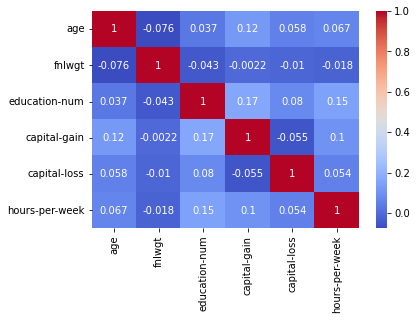

In [12]:
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

#### Missing Data

In [13]:
df.isnull().values.any()

True

In [14]:
nan_count = np.sum(df.isnull(), axis = 0)
nan_count

age                162
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex_selfID           0
capital-gain         0
capital-loss         0
hours-per-week     325
native-country     583
income_binary        0
dtype: int64

In [15]:
nan_cols = list(nan_count[nan_count != 0].index)
print(nan_cols)

['age', 'workclass', 'occupation', 'hours-per-week', 'native-country']


In [16]:
nan_col_types = df[nan_cols].dtypes
nan_col_types

age               float64
workclass          object
occupation         object
hours-per-week    float64
native-country     object
dtype: object

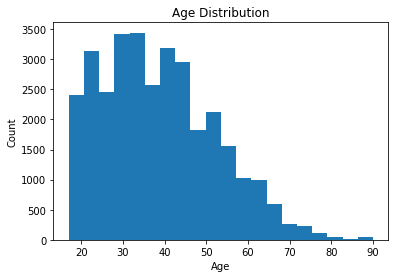

In [17]:
plt.hist(df["age"], bins=20)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution")
plt.show()

In [18]:
print(df["age"].min())
print(df["age"].max())

17.0
90.0


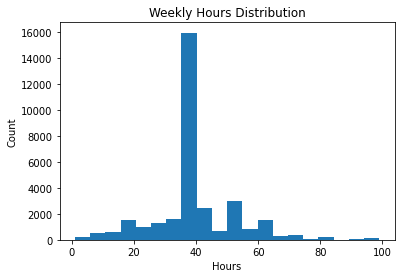

In [19]:
plt.hist(df["hours-per-week"], bins=20)
plt.xlabel("Hours")
plt.ylabel("Count")
plt.title("Weekly Hours Distribution")
plt.show()

In [20]:
print(df["hours-per-week"].min())
print(df["hours-per-week"].max())

1.0
99.0


In [21]:
print(df["capital-gain"].min())
print(df["capital-gain"].max())

0
14084


In [22]:
df["relationship"].unique()

array(['Not-in-family', 'Husband', 'Wife', 'Own-child', 'Unmarried',
       'Other-relative'], dtype=object)

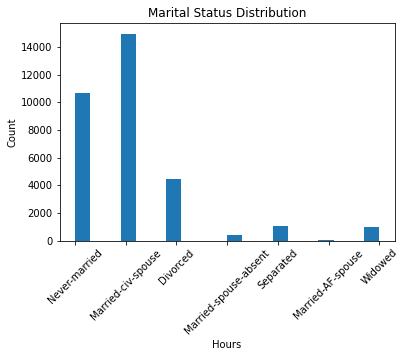

In [23]:
plt.hist(df["marital-status"], bins=20)
plt.xlabel("Hours")
plt.ylabel("Count")
plt.title("Marital Status Distribution")
plt.xticks(rotation=45)
plt.show()

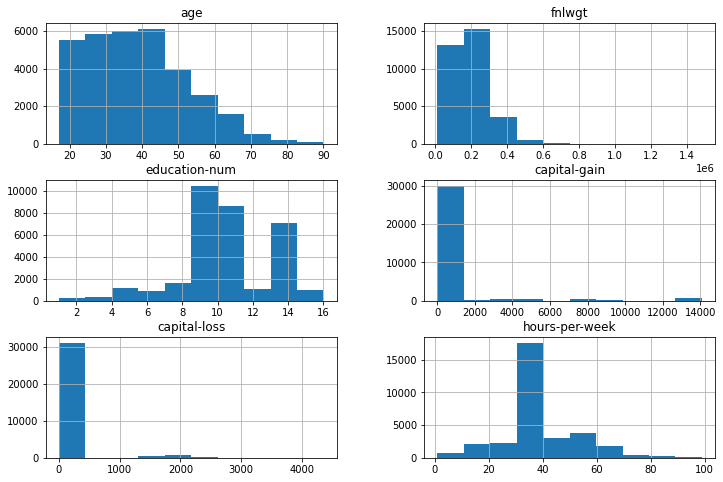

In [24]:
df.hist(figsize=(12, 8))
plt.show()

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]),
 [Text(0, 0, 'Bachelors'),
  Text(1, 0, 'HS-grad'),
  Text(2, 0, '11th'),
  Text(3, 0, 'Masters'),
  Text(4, 0, '9th'),
  Text(5, 0, 'Some-college'),
  Text(6, 0, 'Assoc-acdm'),
  Text(7, 0, 'Assoc-voc'),
  Text(8, 0, '7th-8th'),
  Text(9, 0, 'Doctorate'),
  Text(10, 0, 'Prof-school'),
  Text(11, 0, '5th-6th'),
  Text(12, 0, '10th'),
  Text(13, 0, '1st-4th'),
  Text(14, 0, 'Preschool'),
  Text(15, 0, '12th')])

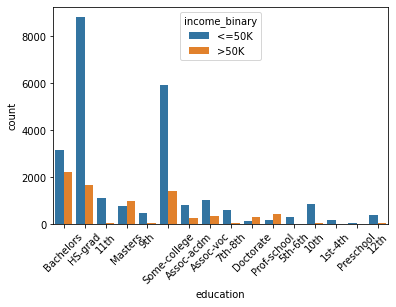

In [25]:
sns.countplot(data=df, x="education", hue="income_binary")
plt.xticks(rotation=45)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13]),
 [Text(0, 0, 'Adm-clerical'),
  Text(1, 0, 'Exec-managerial'),
  Text(2, 0, 'Handlers-cleaners'),
  Text(3, 0, 'Prof-specialty'),
  Text(4, 0, 'Other-service'),
  Text(5, 0, 'Sales'),
  Text(6, 0, 'Craft-repair'),
  Text(7, 0, 'Transport-moving'),
  Text(8, 0, 'Farming-fishing'),
  Text(9, 0, 'Machine-op-inspct'),
  Text(10, 0, 'Tech-support'),
  Text(11, 0, 'Protective-serv'),
  Text(12, 0, 'Armed-Forces'),
  Text(13, 0, 'Priv-house-serv')])

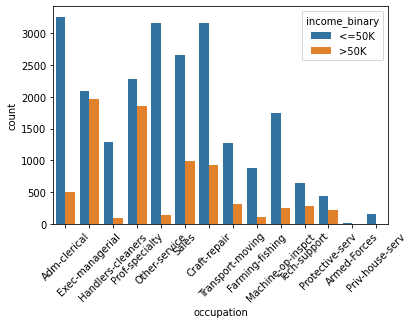

In [26]:
sns.countplot(data=df, x="occupation", hue="income_binary")
plt.xticks(rotation=45)

(array([0, 1, 2, 3, 4, 5, 6, 7]),
 [Text(0, 0, 'State-gov'),
  Text(1, 0, 'Self-emp-not-inc'),
  Text(2, 0, 'Private'),
  Text(3, 0, 'Federal-gov'),
  Text(4, 0, 'Local-gov'),
  Text(5, 0, 'Self-emp-inc'),
  Text(6, 0, 'Without-pay'),
  Text(7, 0, 'Never-worked')])

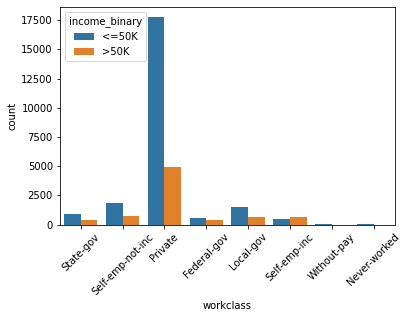

In [27]:
sns.countplot(data=df, x="workclass", hue="income_binary")
plt.xticks(rotation=45)

(array([0, 1]), [Text(0, 0, 'Non-Female'), Text(1, 0, 'Female')])

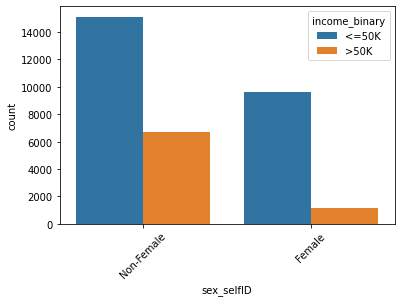

In [28]:
sns.countplot(data=df, x="sex_selfID", hue="income_binary")
plt.xticks(rotation=45)

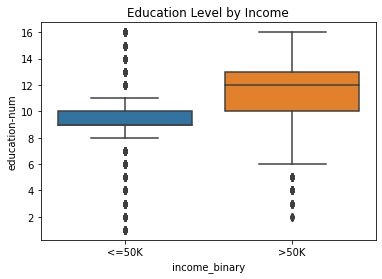

In [29]:
sns.boxplot(data=df, x="income_binary", y="education-num")
plt.title("Education Level by Income")
plt.show()

In [30]:
df["race"].value_counts()

White                 27816
Black                  3124
Asian-Pac-Islander     1039
Amer-Indian-Inuit       311
Other                   271
Name: race, dtype: int64

In [31]:
df["native-country"].value_counts()

United-States                 29170
Mexico                          643
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                     114
El-Salvador                     106
India                           100
Cuba                             95
England                          90
Jamaica                          81
South                            80
China                            75
Italy                            73
Dominican-Republic               70
Vietnam                          67
Guatemala                        64
Japan                            62
Poland                           60
Columbia                         59
Taiwan                           51
Haiti                            44
Iran                             43
Portugal                         37
Nicaragua                        34
Peru                             31
Greece                           29
France                      

In [32]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex_selfID',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income_binary'],
      dtype='object')

### EDA Summary

<b>Task</b>: In the markdown cell below, summarize the key findings from your data exploration. Describe any patterns, anomalies, or data quality issues you identified and explain how those findings may influence your data preparation decisions. For example, your exploration may affect how you handle missing values, address class imbalance, or determine which features to keep or remove.

Some educations are really low, such as pre-school and 1st-4th. These might not be very useful we might not need these values. There is also a class difference. The number of people making less than or equal to 50k annually is almost triple the the amount of people making more than 50k. This might skew our data and we may not have enough data to train our model to predict who makes over 50k. From my EDA, I am considering using age, workclass, education-num, marital-status, occupation, capital-gain/loss, and hours-per-week.

### Ethical Considerations:

Machine learning models can cause harm when they reflect or amplify biases in the data they are trained on. 

<b>Task</b>: In the markdown cell below, answer both of the following questions:

1. What biases or ethical concerns might be present in your dataset? Think about who collected the data, how it was collected, and which groups of people appear in it. Are there features in the dataset that could serve as proxies for protected characteristics like race, gender, or socioeconomic status?
2. Who could be harmed by a model that makes incorrect predictions on this data, and how? Be specific about which groups are most at risk and what the real-world consequences of errors might look like.

1. The census data is from 1994. This was over 20 years ago, and the economy and other factors have changed drastically since then. Therefore, the data may not be accurate. More people would be making over 50k as their salary now compared to 22 years ago. There also could be a bias against women in this dataset. Most of the dataset contains data from White individuals, which could lead to a bias against other races.
2. People who are underrepresented in the dataset could be harmed by the model. This could be women, non-white people, and even people who are not originally from the united states. The real world consequences would be giving a false-negative. Someone could qualify for a loan, but the if the model says they do not qualify, they miss out on a loan they qualify for which could end up harming them financially.

## Part 4: Prepare Your Data

<b>Task</b>: In the code cell below, prepare your data for modeling. The specific steps you take will depend on what you found during your EDA and which model you plan to use. 

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [33]:
# drop missing values for categorical
categorical_cols = ["workclass", "marital-status", "occupation", "native-country"]
df = df.dropna(subset=categorical_cols)

In [34]:
df.shape

(30162, 15)

In [35]:
np.sum(df.isnull(), axis = 0)

age               150
workclass           0
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation          0
relationship        0
race                0
sex_selfID          0
capital-gain        0
capital-loss        0
hours-per-week    297
native-country      0
income_binary       0
dtype: int64

In [36]:
# impute missing values for numeric
df["age"] = df["age"].fillna(df["age"].median())
df["hours-per-week"] = df["hours-per-week"].fillna(df["hours-per-week"].median())

In [37]:
np.sum(df.isnull(), axis = 0)

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex_selfID        0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income_binary     0
dtype: int64

In [38]:
# one-hot encode
categorical_cols.remove("native-country")
df = pd.get_dummies(df, columns=categorical_cols)
df

,age,fnlwgt,education,education-num,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,...,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving
0,39.0,77516,Bachelors,13,Not-in-family,White,Non-Female,2174,0,40.0,...,0,0,0,0,0,0,0,0,0,0
1,50.0,83311,Bachelors,13,Husband,White,Non-Female,0,0,13.0,...,0,0,0,0,0,0,0,0,0,0
2,38.0,215646,HS-grad,9,Not-in-family,White,Non-Female,0,0,40.0,...,0,1,0,0,0,0,0,0,0,0
3,53.0,234721,11th,7,Husband,Black,Non-Female,0,0,40.0,...,0,1,0,0,0,0,0,0,0,0
4,28.0,338409,Bachelors,13,Wife,Black,Female,0,0,40.0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27.0,257302,Assoc-acdm,12,Wife,White,Female,0,0,38.0,...,0,0,0,0,0,0,0,0,1,0
32557,40.0,154374,HS-grad,9,Husband,White,Non-Female,0,0,40.0,...,0,0,1,0,0,0,0,0,0,0
32558,58.0,151910,HS-grad,9,Unmarried,White,Female,0,0,40.0,...,0,0,0,0,0,0,0,0,0,0
32559,22.0,201490,HS-grad,9,Own-child,White,Non-Female,0,0,20.0,...,0,0,0,0,0,0,0,0,0,0


In [39]:
df.columns

Index(['age', 'fnlwgt', 'education', 'education-num', 'relationship', 'race',
       'sex_selfID', 'capital-gain', 'capital-loss', 'hours-per-week',
       'native-country', 'income_binary', 'workclass_Federal-gov',
       'workclass_Local-gov', 'workclass_Private', 'workclass_Self-emp-inc',
       'workclass_Self-emp-not-inc', 'workclass_State-gov',
       'workclass_Without-pay', 'marital-status_Divorced',
       'marital-status_Married-AF-spouse', 'marital-status_Married-civ-spouse',
       'marital-status_Married-spouse-absent', 'marital-status_Never-married',
       'marital-status_Separated', 'marital-status_Widowed',
       'occupation_Adm-clerical', 'occupation_Armed-Forces',
       'occupation_Craft-repair', 'occupation_Exec-managerial',
       'occupation_Farming-fishing', 'occupation_Handlers-cleaners',
       'occupation_Machine-op-inspct', 'occupation_Other-service',
       'occupation_Priv-house-serv', 'occupation_Prof-specialty',
       'occupation_Protective-serv', 'occ

In [40]:
df["income_binary"] = df["income_binary"].map({
    "<=50K": 0,
    ">50K": 1
})

In [41]:
features = df.drop(columns=["income_binary", "fnlwgt", "education",
                           "race", "relationship", "sex_selfID", 
                            "native-country"]).columns.tolist()
label = ["income_binary"]

In [42]:
features

['age',
 'education-num',
 'capital-gain',
 'capital-loss',
 'hours-per-week',
 'workclass_Federal-gov',
 'workclass_Local-gov',
 'workclass_Private',
 'workclass_Self-emp-inc',
 'workclass_Self-emp-not-inc',
 'workclass_State-gov',
 'workclass_Without-pay',
 'marital-status_Divorced',
 'marital-status_Married-AF-spouse',
 'marital-status_Married-civ-spouse',
 'marital-status_Married-spouse-absent',
 'marital-status_Never-married',
 'marital-status_Separated',
 'marital-status_Widowed',
 'occupation_Adm-clerical',
 'occupation_Armed-Forces',
 'occupation_Craft-repair',
 'occupation_Exec-managerial',
 'occupation_Farming-fishing',
 'occupation_Handlers-cleaners',
 'occupation_Machine-op-inspct',
 'occupation_Other-service',
 'occupation_Priv-house-serv',
 'occupation_Prof-specialty',
 'occupation_Protective-serv',
 'occupation_Sales',
 'occupation_Tech-support',
 'occupation_Transport-moving']

### Data Preparation Summary:

<b>Task</b>: In the markdown cell below, document the data preparation steps you took. For each decision, explain why you made it. For example, why did you handle missing values the way you did? Why did you keep or remove certain features? If a preparation step depends on the model you selected (for example, scaling for KNN but not for a decision tree), explain that as well.

First, I dropped the missing values for the categorical variables workclass, occupation, and native country. I chose to handle the missing values for native country althought I am not using it as a feature for my model. Then I handled the missing values for the numerical variables age and hours per week by substituting them with the median values. Then, I one-hot encoded the categorical variables workclass, marital status, and occupation. Finally, I chose my features. I chose not to use race, sex, and native country because of possible biases. I chose not to use relationship because we have marital status. I also made it so that income_binary contained 0s and 1s.

## Part 5: Train, Test, Evaluate, and Improve a Traditional Machine Learning Model

Now you will train, test and evaluate your model. You will also use model selection techniques to improve your model's performance by identifying the optimal hyperparameter configuration.

<b>Task</b>: In the code cells below, do the following:

1. Create labeled examples from the dataset
2. Create training and test sets out of the labeled examples 
3. Train, test and evaluate your model 
    * You must evaluate your model using accuracy and F1 score. Use `accuracy_score` and `f1_score` from `sklearn.metrics`. For the F1 score, use `average='binary'` since this is a binary classification problem. You will compare your model's performance to that of a neural network later in this capstone. Save the results of your evaluation metrics to variables for later comparison.
    * You may use additional evaluation metrics of your choosing.
4. Perform model selection through grid search cross-validation to identify optimal hyperparameter values for your model
5. Train, test and evaluate a final version of your model using the optimal hyperparameter configuration.
6. Interpret your model's outputs in the context of the business problem. Depending on the model you chose, this might mean:
    * KNN: Describe what your model's performance metrics tell you about its behavior. For example: How does accuracy change as you vary k? What does that suggest about the structure of your data?
    * Decision Tree: print or plot feature importances.
    * Logistic Regression: print or plot the model coefficients.



<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [43]:
# Create labeled examples from the dataset
X = df[features]
y = df[label]

In [44]:
# Create training and test sets out of the labeled examples 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)

In [45]:
# Train, test and evaluate your model
model = DecisionTreeClassifier(criterion = 'entropy', max_depth = 8, min_samples_leaf = 1)
model.fit(X_train, y_train)

class_label_predictions = model.predict(X_test)

acc_score = accuracy_score(y_test, class_label_predictions)
f1 = f1_score(y_test, class_label_predictions, average="binary")
print(acc_score)
print(f1)

0.8529119239694994
0.6477904207462292


In [46]:
# Perform model selection through grid search cross-validation (GridSearchCV)
# to identify optimal hyperparameter values for your model
param_grid = {
    "max_depth": [4,8,16],
    "min_samples_leaf": [25,50,100]
}
model = DecisionTreeClassifier()
grid = GridSearchCV(estimator = model, param_grid = param_grid, cv=5, scoring = "accuracy")

grid_search = grid.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best accuracy:", grid_search.best_score_)

Best parameters: {'max_depth': 16, 'min_samples_leaf': 25}
Best accuracy: 0.8508976188123215


In [47]:
# Train, test and evaluate a final version of your model using the optimal hyperparameter values.
model = DecisionTreeClassifier(criterion = 'entropy', max_depth = 16, min_samples_leaf = 25)
model.fit(X_train, y_train)

class_label_predictions = model.predict(X_test)

acc_score = accuracy_score(y_test, class_label_predictions)
f1 = f1_score(y_test, class_label_predictions, average="binary")
print(acc_score)
print(f1)

0.8543485468007515
0.67279046673287


In [48]:
# Interpret your model's outputs 
feature_imp = model.feature_importances_
df_features = pd.DataFrame({'name': X_train.columns.values, 'imp': feature_imp})
df_sorted = df_features.sort_values(by='imp', ascending=False)
df_sorted

,name,imp
14,marital-status_Married-civ-spouse,0.382615
1,education-num,0.191470
2,capital-gain,0.175021
0,age,0.094980
4,hours-per-week,0.050913
3,capital-loss,0.037795
22,occupation_Exec-managerial,0.011363
7,workclass_Private,0.006979
28,occupation_Prof-specialty,0.006195
23,occupation_Farming-fishing,0.004429


### Model Reflection:

<b>Task</b>: In the markdown cell below, answer the following questions:

1. Which model did you choose and why? Reference your problem and data characteristics in your explanation.
2. What did you learn through the model selection process?
3. How do you interpret your model's outputs? What do the predictions or coefficients or feature importances actually mean in the context of your problem?
4. Are there any fairness or ethical concerns with your model? Who might be harmed by incorrect predictions, and are any groups more likely to be affected?

1. I chose decision tree because the model is easy to interpret for our problem, which is prediciting income to help decide loan eligibility. I chose this model because it can help us model the relationships between our features: age, occupation, education-num, workclass, marital-status, and capital-gain/loss.
2. I learned that it can be difficult to find the most optimal parameters. The parameters you test might not be the most optimal parameters, meaning you might not have the most accurate model possible.
3. The accuracy is 85%, which is pretty good. However, the F1 score is 67% which should be improved. The F1 score measures precision and recall, which is very important for this business problem.
4. If there are false negatives from our model, which is possible, this can negatively affect someone who is in need of a loan.

---
## ✔️ Unit 5 Checkpoint

**Stop here.** If you have completed Parts 1 through 5, you are done with the Unit 5 portion of this capstone.

Parts 6 and 7 require you to train and evaluate a neural network. You will learn about neural networks in the Unit 6 asynchronous content. Do not start Part 6 until you have completed that material and your lab facilitator has directed you to continue. Do not submit your work for grading until you complete Parts 6 and 7.

Make sure your notebook is saved before you close it.

---
## Part 6: Train, Test, Evaluate and Improve a Neural Network

> **⚠️ Before you write any code in Part 6, do this first.**
> 
> Your notebook does not retain variables between sessions. All of your variables and everything else need to be restored to memory before any code below will work.
> 
> Go to **Kernel > Restart & Run All** to re-run Parts 1 through 5, then scroll back here to continue. If you skip this step, you will see a `NameError` on the first code cell below.

Now you will apply a neural network to the same problem and dataset. You will use Keras to build a feedforward neural network for binary classification.

The scaffolding below will walk you through the steps. Where you see a **Task**, fill in the code. Where you see a **Decision**, you are making an independent choice about your architecture or training process. For each decision, add a comment explaining what you chose and why.


### Prepare Your Data for the Neural Network

Neural networks require all input features to be numeric and scaled. If your features are on very different scales (for example, one feature ranges from 0 to 90 and another from 0 to 99999), the model may train less effectively and have difficulty learning meaningful patterns from the data.

Before training your network, create scaled versions of your training and test data. Use `StandardScaler()` from `sklearn.preprocessing` to standardize your features: 

<b>Task</b>: Complete the code cell below to fit the scaler on your training data, then transform both training and test sets. Save the results to new variables (for example, `X_train_scaled` and `X_test_scaled`) so your original data remains available for reference.

**Note:** Use your scaled data for all neural network steps below.

In [49]:
# Scale your data for the neural network

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the test data
X_test_scaled = scaler.transform(X_test)

### Step 1: Define Your Model Architecture

You will use the Keras `Sequential` class to build your network. Your network should have:

- An input layer with the correct shape for your data
- At least two hidden layers using the `Dense` class
- An output layer appropriate for binary classification

<b>Task:</b> Create a `Sequential` model object and name it `nn_model`. Then construct and add each layer.

**Decision:** How many hidden layers will you use? How many units in each? What activation function will you use for the hidden layers? Add a comment explaining your choices.

In [50]:
# Get the number of features in your training data
n_features = X_train_scaled.shape[1]

# Create the neural network model
nn_model = keras.Sequential()

# Create the input layer and add the input layer to the 'nn_model' object
input_layer = keras.layers.InputLayer(input_shape=(n_features,))
nn_model.add(input_layer)

# Create the hidden layers and add the hidden layers to the 'nn_model' object
# Decision: How many layers? How many units? What activation function?
# Add a comment explaining your choices.
hidden_layer_1 = keras.layers.Dense(units=32, activation='relu')
hidden_layer_2 = keras.layers.Dense(units=16, activation='relu')
nn_model.add(hidden_layer_1)
nn_model.add(hidden_layer_2)

# I chose 2 layers and the units 32, thn 16. I chose these to keep the model
# simple enough where it can identify patterns in the data, but not too complex
# and to prevent overfitting. I also chose ReLU because it works simply, but is
# much better for complex / nonlinear models.

# Create the output layer and add the output layer to the 'nn_model' object
# Use the correct number of units and activation function for binary classification
output_layer = keras.layers.Dense(units=1, activation='sigmoid')
nn_model.add(output_layer)

# Print a summary of your model
nn_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 32)                1088      
_________________________________________________________________
dense_1 (Dense)              (None, 16)                528       
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 17        
Total params: 1,633
Trainable params: 1,633
Non-trainable params: 0
_________________________________________________________________


### Step 2:  Define the Optimization Function

<b>Task:</b> In the code cell below, create an optimizer object. Use stochastic gradient descent (SGD) with a learning rate of your choosing.

**Decision:** What learning rate will you use? Add a comment explaining your choice.

In [51]:
# Decision: What learning rate will you use? Add a comment explaining your decision.

sgd_optimizer = keras.optimizers.SGD(learning_rate=0.1)

# I chose 0.1 because it is not high enough where the model will easily converge, 
# but not low enough that training will be slow.

### Step 3: Define the Loss Function

<b>Task:</b> In the code cell below, create a binary cross entropy loss function using `keras.losses.BinaryCrossentropy()`. Use  the parameter `from_logits=False`. 

In [52]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

### Step 4: Compile the Model

<b>Task:</b> In the code cell below, package the network architecture with the optimizer and the loss function using the `compile()` method. Use the `accuracy` evaluation metric.

In [53]:
nn_model.compile(optimizer=sgd_optimizer, 
                 loss=loss_fn, 
                 metrics = ['accuracy'])

### Step 5: Fit the Model to the Training Data

We will define our own callback class to output information from our model while it is training. Make sure you execute the code cell below so that it can be used in subsequent cells.

In [54]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))


<b>Task:</b> Use the `fit()` method to fit your model to the training data. Save the result to variable `history.`

Use the `validation_split` parameter to reserve a portion of your training data for validation during training (a common choice is `validation_split=0.2`). After each epoch, the model is evaluated on this validation data, allowing you to monitor how well the model generalizes and helping you detect overfitting.

Also, use the the logger class defined above to track training progress.

**Decision:** How many epochs will you train for? Add a comment explaining your choice.

**Note:** This may take a while to run.

In [55]:
# Decision: How many epochs? Add a comment.

t0 = time.time() # start time

num_epochs = 40  # I chose 40 so that it wont overfit, but can still train well and improve accuracy.

history = nn_model.fit(
    X_train_scaled,
    y_train,
    epochs=num_epochs,
    validation_split=0.2
)

t1 = time.time() # stop time

print('Elapsed time: %.2fs' % (t1-t0))

Epoch 1/40
528/528 [==============================] - 1s 2ms/step - loss: 0.3610 - accuracy: 0.8321 - val_loss: 0.3305 - val_accuracy: 0.8470
Epoch 2/40
528/528 [==============================] - 1s 1ms/step - loss: 0.3306 - accuracy: 0.8475 - val_loss: 0.3257 - val_accuracy: 0.8525
Epoch 3/40
528/528 [==============================] - 1s 1ms/step - loss: 0.3258 - accuracy: 0.8490 - val_loss: 0.3220 - val_accuracy: 0.8508
Epoch 4/40
528/528 [==============================] - 1s 1ms/step - loss: 0.3226 - accuracy: 0.8509 - val_loss: 0.3227 - val_accuracy: 0.8496
Epoch 5/40
528/528 [==============================] - 1s 1ms/step - loss: 0.3201 - accuracy: 0.8508 - val_loss: 0.3183 - val_accuracy: 0.8503
Epoch 6/40
528/528 [==============================] - 1s 1ms/step - loss: 0.3184 - accuracy: 0.8506 - val_loss: 0.3185 - val_accuracy: 0.8522
Epoch 7/40
528/528 [==============================] - 1s 1ms/step - loss: 0.3166 - accuracy: 0.8548 - val_loss: 0.3260 - val_accuracy: 0.8511
Epoch 

### Step 6: Visualize Training Performance

<b>Task:</b>  

Create two plots to visualize the model's performance over time:
1. Training loss and validation loss over epochs, on the same axes.
2. Training accuracy and validation accuracy over epochs, on the same axes.

Label your axes and include a legend.

Use the `history` object returned by `fit()` to obtain this information. 



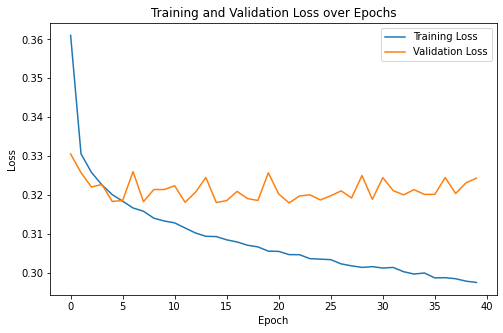

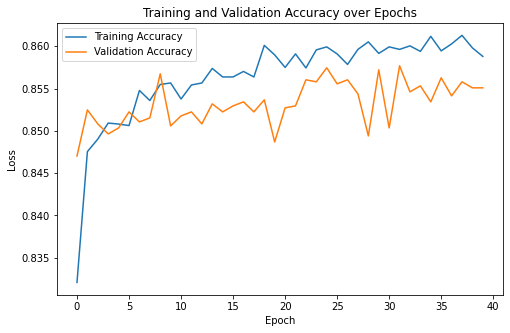

In [56]:
# Plot training loss and validation loss over epochs
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss over Epochs")
plt.legend()

plt.show()

# Plot training accuracy and validation accuracy over epochs
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Accuracy over Epochs")
plt.legend()

plt.show()

### Step 7: Evaluate the Model's Performance on the Test Set

<b>Task:</b> Use your neural network to generate predictions on the test set and evaluate its performance using accuracy and F1 score. Use `nn_model.predict()` to generate predictions. Since `nn_model.predict()` returns probabilities, apply a threshold of 0.5 to convert probabilities into binary class predictions before computing your metrics. Save your accuracy and F1 score results to clearly named variables so you can compare them to the results from your previous model. Print the results.

In [57]:
# Generate predictions from your neural network using your scaled test data
# nn_model.predict() returns probabilities — apply a threshold of 0.5 to get class labels

probability_predictions = nn_model.predict(X_test_scaled)
class_label_predictions=[]

for i in range(0, len(y_test)):
    if probability_predictions[i] >= 0.5:
        class_label_predictions.append(1)
    else:
        class_label_predictions.append(0)

In [58]:
# Compute accuracy and F1 score for the neural network and print the results

nn_accuracy = accuracy_score(y_test, class_label_predictions)
nn_f1 = f1_score(y_test, class_label_predictions, average="binary")

print("Accuracy score: ", nn_accuracy)
print("F1 score: ", nn_f1)

Accuracy score:  0.8521383578295945
F1 score:  0.6669985067197611


#### Neural Network Reflection:

<b>Task:</b> In the markdown cell below, answer the following questions:

1. Walk through the architecture decisions you made: number of layers, number of units, activation functions, learning rate, and number of epochs. Why did you make each of those choices?
2. What did your training curves tell you? Did you see any signs of overfitting or underfitting?
3. How did your neural network perform on the test set? Report your accuracy and F1 score here and note whether the result surprised you given what your training curves showed.

1. I chose to use 2 hidden layers to allow the model to be complex enough to find patterns in our data, but not too complex. Adding a third layer would likely make the model too complex for our dataset and lead to overfitting. I tested this to confirm my original thoughts, and adding a third layer led to my model overfitting. I chose 32 and 16 units because, similary, it reduces over complexity and overfitting. I chose the learning rate 0.1 because it was not too high and not too low, preventing the model from converging during training. I noticed that making the rate led to overfitting in the model. I chose 40 epochs so that the model wouldn't overtrain, but would have enough iterations to learn the patterns.
2. The training curves helped visualize the increase or decrease in both accuracy and validation over epochs, and if there was overfitting by seeing the difference between test and validation values. This helped identify if any changes should be made, and helped me tune my model.
3. The test data did well, with around 85.3% accuracy and 69.5% f1 score. The accuracy score was similar to the validation accuracy from the graph, but was not as high as the training accuracy (as expected).

## Part 7: Compare Your Models and Reflect

You have now applied two different approaches to the same problem. In this final section, you will put those results side by side and reflect on what you learned.

###  Results Summary

<b>Task:</b> In the code cell below, create a summary table using a Pandas DataFrame that displays each evaluation metric for both models side by side. Use the variables you created for the accuracy and F1 score metrics. The table should make it easy to compare performance at a glance across every metric you computed.

In [59]:
# Build a side-by-side comparison of your two models using the metric variables
# you created. For example:

results = pd.DataFrame({
 'Metric': ['Accuracy', 'F1 Score'],
 'Decision Tree Model': [acc_score, f1],
 'Neural Network': [nn_accuracy, nn_f1]
})
 
print(results.to_string(index=False))


   Metric  Decision Tree Model  Neural Network
 Accuracy             0.854349        0.852138
 F1 Score             0.672790        0.666999


### Comparative Analysis

<b>Task:</b> In the markdown cell below, write a comparative analysis that addresses the following. 

1. **Performance comparison.** How did the two models perform relative to each other? Which metrics improved, which stayed the same, and which got worse?

2. **Was the added complexity worth it?** Neural networks are more complex to build, tune, and interpret. Given the performance difference you observed, do you think the neural network justified that added complexity for this problem?

3. **Recommendation.** If you were presenting this work to your company and their client as described in the business brief, which model would you recommend deploying and why? Consider not just performance but also interpretability, training time, and what the costs of different types of errors look like for that specific client.

4. **What you would do next.** If you had more time, what would you try to improve your results? This could include trying different architectures, additional preprocessing steps, different features, or techniques to address class imbalance. Be specific.

1. There isn't much of a big difference in accuracy between the two models. The accuracy for the Neural Network is only about 0.1% less. The f1 score, however, is a little bit over 2% higher for the Neural Network.
2. Initially, I thought it wasn't worth it because the accuracy scores were the same. After seeing an improvement in the f1 score, however, I think the added complexity of the neural network was worth it. Since f1 is a measure of precision and recall, it is incredibly important, especially for our problem, to have the highest f1 score possible. 
3. I would recommend using the Neural Network because there is a higher f1 score, which is important for the business problem. It is important to consider that there still might be errors with the model given that the accuracy and f1 scores are not equal to 100%. The training did not take too long for our dataset, but if the client uses a larger dataset, it might take a little bit longer. However, the training time would not be long enough to be a deal breaker. I also noticed that the accuracy and f1 scores change during different runs/training runs. This might not have a large impact, but is importat to note.
4. If I had more time, I would try to adjust the architecture, such as the layers, learning rate, etc., to optimize the model. I would also try to do feature selection methods to select the most important features to see if that improves the moel performance.

---
## AI Use Attestation

Reflect honestly on how you used AI tools during this capstone. You are expected to have used AI somewhere in your workflow, and your reflection on that use is what will be evaluated: How clearly you describe your choices, how you verified your work, and what you learned from the process. If you chose not to use AI, explain why. Answer each question in the markdown cell below.

1. Where and at what stages of this capstone did you use AI tools, for example, Claude during brainstorming, coding, or debugging? If you chose not to use AI, explain why.
2. Identify one part of the capstone that required the most effort or thought. What made it challenging, and how did you work through it, with AI or without AI? If you used AI at this point, feel free to share a prompt that worked well or one that did not land the way you expected.
3. How did you verify that your work was correct? What did you look for to catch a mistake, whether it came from AI output or your own reasoning?
4. What is one thing you would do differently next time, either in how you approached the capstone or in how you used AI during it?

1. I used AI/ChatGPT during data preparation. This was difficult for me since all of the methods we learned over a month ago, so I could not remember some of the techniques. I used AI to help me brainstorm ways to approach the EDA process and get started with EDA. Later in the data preparation process, I was able to come up with questions and explore the dataset on my own. Throughout the capstone, I would ask AI to help me when I got stumped with syntax, which has been a problem I have been facing frequently. I also used AI in "tutor mode" during the model creation, asking it to guide me throught the steps and only referencing it when I needed guidance. I would also ask for guidance for parameters. I did the same for the neural networks, although this was more difficult and I needed it to explain some concepts during the process.
2. The neural networks part required the most effort and thought. It was challenging because all of the concepts were difficult in the first place, so translating it to code while understanding what I was doing was difficult. I used AI to help me with architectural decisions, concepts, and syntax, when I felt stuck.
3. I cross referenced the output with my own knowledge. If I felt that an answer was not correct, I asked AI to explain it, and see if its explanation matched with mine, or if I was able to understand it.
4. I think I would spend more time optimizing the parameters, especially for the neural network. This would allow it to perform better, but it would take a long time to do so.